# Añadir Capas: hacia una red profunda
**Basado en**: *Neural Networks from Scratch* - Capítulo 3 (Adding Layers)

**Objetivo**: entender por que apilamos capas y qué significa "profundo".
Una red neuronal se vuelve profunda cuando tiene 2 o más capas ocultas.
Este notebook construye esa profundidad desde cero y muestra por que los datos
no lineales requieren más de una capa.

**Estructura del notebook:**
1. Dos capas densas - cálculo manual
2. La clase `Layer_Dense` - diseño reutilizable
3. Datos de entrenamiento no lineales - spiral_data
4. Red de dos capas con datos reales
5. Visualización: por que los datos no lineales son un problema
6. Ejercicio de decisión

---

In [1]:
# Instalar nnfs si no está disponible (solo la primera vez)
%pip install -q nnfs

import numpy as np
import matplotlib.pyplot as plt
import nnfs
from nnfs.datasets import spiral_data
import os

np.random.seed(0)  # seed fijo para reproducibilidad (sin sobreescribir np.dot)
os.makedirs('images', exist_ok=True)
%matplotlib inline
print(f'NumPy {np.__version__}')
print('[OK] Entorno listo')


Note: you may need to restart the kernel to use updated packages.
NumPy 1.26.4
[OK] Entorno listo


---
## 1. Dos capas densas - cálculo manual

En el B03A calculamos la salida de una sola capa.
Ahora encadenamos dos: **la salida de la capa 1 es la entrada de la capa 2**.

Restricción de dimensiones:
- Capa 1: 4 entradas → 3 salidas (3 neuronas)
- Capa 2: **debe recibir 3 entradas** (igual que las salidas de la capa 1) → puede tener N salidas

```
X (3, 4) → Layer1 (4→3) → layer1_out (3, 3)
                        → Layer2 (3→3) → layer2_out (3, 3)
```

Las capas entre la entrada y la salida se llaman **capas ocultas** (*hidden layers*).
"Ocultas" porque el científico de datos no las ve directamente:
solo ve los datos de entrada y las predicciones finales.

In [2]:
# Dos capas densas encadenadas - cálculo directo con np.dot

# Batch de 3 muestras, 4 features cada una
import numpy as np
import nnfs
nnfs.init()

# 1. Convertir todo a np.array desde el inicio
inputs = np.array([
    [1,    2,    3,    2.5],
    [2.,   5.,  -1.,   2.],
    [-1.5, 2.7,  3.3, -0.8],
])

weights = np.array([
    [0.2,   0.8,  -0.5,  1.],
    [0.5,  -0.91,  0.26, -0.5],
    [-0.26, -0.27,  0.17,  0.87],
])
biases = np.array([2, 3, 0.5])

weights2 = np.array([
    [0.1,  -0.14,  0.5],
    [-0.5,  0.12, -0.33],
    [-0.44, 0.73, -0.13],
])
biases2 = np.array([-1, 2, -0.5])

# Forward pass (Ahora np.dot recibirá objetos de numpy correctamente)
layer1_outputs = np.dot(inputs, weights.T) + biases
layer2_outputs = np.dot(layer1_outputs, weights2.T) + biases2

print('layer1_outputs shape:', layer1_outputs.shape)
print('layer2_outputs shape:', layer2_outputs.shape)
print('\nlayer2_outputs:')
print(layer2_outputs)
# esperado: [[ 0.5031  -1.04185 -2.03875]
#            [ 0.2434  -2.7332  -5.7633 ]
#            [-0.99314  1.41254 -0.35655]]

layer1_outputs shape: (3, 3)
layer2_outputs shape: (3, 3)

layer2_outputs:
[[ 0.50310004 -1.04184985 -2.03874993]
 [ 0.24339998 -2.73320007 -5.76329994]
 [-0.99314     1.41254002 -0.35655001]]


---
## 2. La clase `Layer_Dense`

Codificar pesos a mano no escala. Necesitamos una clase reutilizable.

Decisiones de diseño:

- **Pesos inicializados con `0.01 * np.random.randn(n_inputs, n_neurons)`**:
 - Gaussiana centrada en 0 (valores positivos y negativos)
 - Multiplicada por 0.01 para que sean pequeños al inicio
 - Si empezasen grandes, los gradientes serían enormes y el entrenamiento inestable

- **Sesgos inicializados a cero con `np.zeros((1, n_neurons))`**:
 - Iniciar en cero es el default mas comun
 - En algunos casos (neuronas "muertas" con ReLU) se usan valores pequeños positivos

- **Pesos en shape `(n_inputs, n_neurons)`** (no transpuesta):
 - Hacemos la transposicion una sola vez al inicializar
 - En el forward pass: `np.dot(inputs, self.weights)` sin necesidad de `.T`

```
                  np.random.randn(n_inputs, n_neurons)
weights shape: (n_inputs, n_neurons)  <-- ya en el orden correcto para dot
biases  shape: (1, n_neurons)         <-- broadcasting: se suma a cada fila
output  shape: (batch_size, n_neurons)
```

In [3]:
# La clase Layer_Dense - tal como la define el libro NNFS

class Layer_Dense:
    # Inicializacion de la capa
    def __init__(self, n_inputs, n_neurons):
        # Pesos: shape (n_inputs, n_neurons)
        # ya en el orden correcto para np.dot(inputs, weights)
        self.weights = 0.01 * np.random.randn(n_inputs, n_neurons)
        # Sesgos: shape (1, n_neurons), broadcasting con el resultado de dot
        self.biases = np.zeros((1, n_neurons))

    # Forward pass
    def forward(self, inputs):
        # output = inputs @ weights + biases
        self.output = np.dot(inputs, self.weights) + self.biases


# Verificacion: mismos datos que antes, ahora con la clase
print('Verificacion de inicializacion (seed fijado por nnfs.init):')
capa_test = Layer_Dense(n_inputs=2, n_neurons=4)
print('weights shape:', capa_test.weights.shape)
print('biases  shape:', capa_test.biases.shape)
print('weights:\n', capa_test.weights)
print('biases:\n',  capa_test.biases)

Verificacion de inicializacion (seed fijado por nnfs.init):
weights shape: (2, 4)
biases  shape: (1, 4)
weights:
 [[ 0.01764052  0.00400157  0.00978738  0.02240893]
 [ 0.01867558 -0.00977278  0.00950088 -0.00151357]]
biases:
 [[0. 0. 0. 0.]]


---
## 3. Datos de entrenamiento no lineales - spiral_data

Hasta ahora usábamos datos inventados. Los datos reales tienen estructura compleja.
Para estudiar como aprende una red, usamos **spiral_data**: un dataset sintético
con clases en espiral - no lineal por construcción.

¿Por que espirales?
- **Datos lineales** (como dos gaussianas separadas): cualquier modelo simple los separa.
  Una línea recta basta.
- **Datos no lineales** (como espirales): ningún modelo lineal puede separarlos.
  Se necesitan capas ocultas con activaciones no lineales.

Este dataset sirve para demostrar exactamente el punto donde las redes profundas
superan a los modelos lineales.

> `spiral_data(samples=N, classes=K)` genera N muestras por clase,
> K clases en espiral. Devuelve `X` de shape `(N*K, 2)` e `y` de shape `(N*K,)`.

X shape: (300, 2)  (300 muestras, 2 features)
y shape: (300,)  (300 etiquetas de clase 0/1/2)
Clases: [0 1 2]


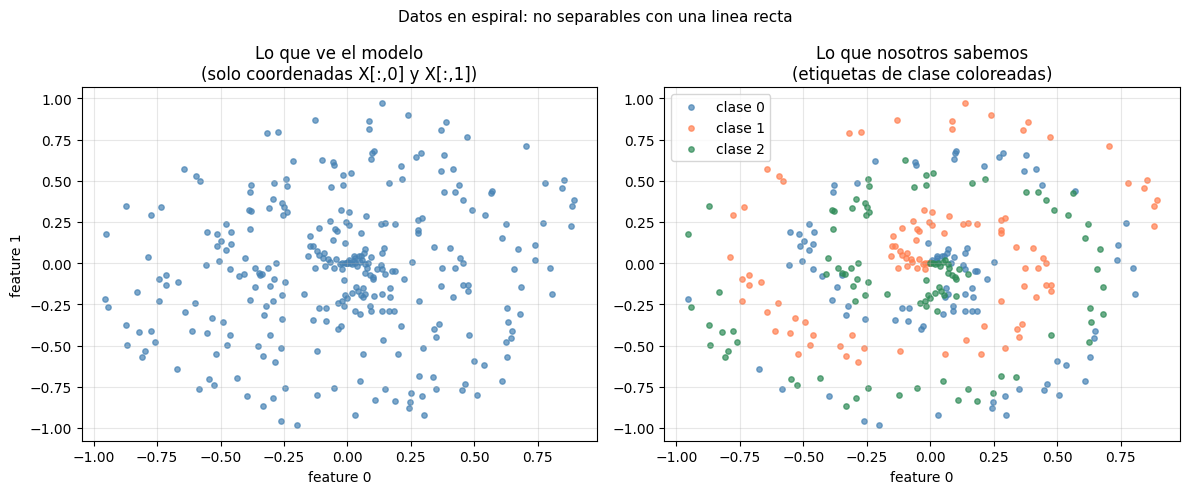

In [4]:
# Generar y visualizar el dataset espiral

X, y = spiral_data(samples=100, classes=3)

print(f'X shape: {X.shape}  (300 muestras, 2 features)')
print(f'y shape: {y.shape}  (300 etiquetas de clase 0/1/2)')
print(f'Clases: {np.unique(y)}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Sin color (lo que ve la red: solo coordenadas)
axes[0].scatter(X[:, 0], X[:, 1], s=15, alpha=0.7, color='steelblue')
axes[0].set_title('Lo que ve el modelo\n(solo coordenadas X[:,0] y X[:,1])')
axes[0].set_xlabel('feature 0')
axes[0].set_ylabel('feature 1')
axes[0].grid(True, alpha=0.3)

# Con color (lo que nosotros sabemos)
colores = ['steelblue', 'coral', 'seagreen']
for clase in range(3):
    mask = y == clase
    axes[1].scatter(X[mask, 0], X[mask, 1], s=15, alpha=0.7,
                    color=colores[clase], label=f'clase {clase}')
axes[1].set_title('Lo que nosotros sabemos\n(etiquetas de clase coloreadas)')
axes[1].set_xlabel('feature 0')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Datos en espiral: no separables con una linea recta', fontsize=11)
plt.tight_layout()
plt.savefig('images/B03B_fig01.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close('all')

In [5]:
# Por que falla un modelo lineal en datos en espiral
# Un modelo lineal dibuja fronteras de decision rectas
# Las espirales no son separables con lineas rectas

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X, y)
y_pred = clf.predict(X)
acc = accuracy_score(y, y_pred)

print(f'Accuracy de regresion logistica (modelo lineal): {acc:.3f}')
print()
print('Interpretacion:')
print(' - Accuracy ~0.33 significa que predice al azar (3 clases equiprobables)')
print(' - Un modelo lineal no puede aprender la geometria en espiral')
print(' - Se necesita no linealidad: capas ocultas + funciones de activacion')

Accuracy de regresion logistica (modelo lineal): 0.417

Interpretacion:
 - Accuracy ~0.33 significa que predice al azar (3 clases equiprobables)
 - Un modelo lineal no puede aprender la geometria en espiral
 - Se necesita no linealidad: capas ocultas + funciones de activacion


---
## 4. Red de dos capas con datos reales

Ahora usamos la clase `Layer_Dense` con los datos en espiral.

Pipeline:
```
X (300, 2)  ->  dense1 (2 inputs, 3 neurons)  ->  (300, 3)
            ->  dense2 (3 inputs, 3 neurons)  ->  (300, 3)
```

Los outputs de la segunda capa son **logits** - números reales sin interpretar todavía.
Para convertirlos en probabilidades necesitaremos Softmax (B03C).

> Con pesos aleatorios, las predicciones son ruido.
> El entrenamiento (B03D → B04) ajustará los pesos para que las predicciones sean correctas.

In [6]:
# Red de 2 capas densas con spiral_data
# Codigo completo siguiendo el libro NNFS

import numpy as np
import nnfs
from nnfs.datasets import spiral_data

nnfs.init()

# Generar dataset
X, y = spiral_data(samples=100, classes=3)

# Capa 1: 2 features de entrada, 3 neuronas de salida
dense1 = Layer_Dense(n_inputs=2, n_neurons=3)

# Capa 2: 3 entradas (= salidas de dense1), 3 neuronas de salida (= 3 clases)
dense2 = Layer_Dense(n_inputs=3, n_neurons=3)

# Forward pass
dense1.forward(X)
dense2.forward(dense1.output)

print('dense1.output shape:', dense1.output.shape)
print('dense2.output shape:', dense2.output.shape)
print()
print('Primeras 5 salidas de la red (logits, pesos aleatorios):')
print(dense2.output[:5])
print()
print('[!] Estas salidas son ruido: los pesos son aleatorios.')
print('    El proximo paso (B03C) añade Softmax para convertirlas en probabilidades.')

dense1.output shape: (300, 3)
dense2.output shape: (300, 3)

Primeras 5 salidas de la red (logits, pesos aleatorios):
[[0.0000000e+00 0.0000000e+00 0.0000000e+00]
 [1.7565117e-06 1.6089588e-06 6.8606624e-07]
 [4.1309927e-06 3.9028992e-06 1.8521655e-06]
 [5.4186435e-06 5.3859658e-06 2.9643538e-06]
 [7.5680446e-06 7.4703939e-06 4.0358373e-06]]

[!] Estas salidas son ruido: los pesos son aleatorios.
    El proximo paso (B03C) añade Softmax para convertirlas en probabilidades.


In [7]:
# Regla de dimensiones para apilar capas
# La restriccion es: n_inputs de la capa N = n_neurons de la capa N-1

print('=== Regla de compatibilidad de dimensiones ===')
print()
print('Entrada    : X.shape = (300, 2)  -> 300 muestras, 2 features')
print()
print('Capa 1:')
print(f'  weights.shape = {dense1.weights.shape}  (n_inputs=2, n_neurons=3)')
print(f'  biases.shape  = {dense1.biases.shape}')
print(f'  output.shape  = {dense1.output.shape}  (batch=300, n_neurons=3)')
print()
print('Capa 2:')
print(f'  weights.shape = {dense2.weights.shape}  (n_inputs=3 == neuronas capa1, n_neurons=3)')
print(f'  biases.shape  = {dense2.biases.shape}')
print(f'  output.shape  = {dense2.output.shape}  (batch=300, n_neurons=3)')
print()

# Intento de capa incompatible
try:
    capa_incompatible = Layer_Dense(n_inputs=5, n_neurons=3)  # espera 5 entradas
    capa_incompatible.forward(dense1.output)  # dense1 produce 3 salidas, no 5
    print('Ejecuto sin error (inesperado)')
except ValueError as e:
    print(f'[ERROR esperado] Dimensiones incompatibles: {e}')
    print('-> n_inputs de la siguiente capa debe coincidir con n_neurons de la anterior')

=== Regla de compatibilidad de dimensiones ===

Entrada    : X.shape = (300, 2)  -> 300 muestras, 2 features

Capa 1:
  weights.shape = (2, 3)  (n_inputs=2, n_neurons=3)
  biases.shape  = (1, 3)
  output.shape  = (300, 3)  (batch=300, n_neurons=3)

Capa 2:
  weights.shape = (3, 3)  (n_inputs=3 == neuronas capa1, n_neurons=3)
  biases.shape  = (1, 3)
  output.shape  = (300, 3)  (batch=300, n_neurons=3)

[ERROR esperado] Dimensiones incompatibles: shapes (300,3) and (5,3) not aligned: 3 (dim 1) != 5 (dim 0)
-> n_inputs de la siguiente capa debe coincidir con n_neurons de la anterior


---
## 5. Visualización: activaciones de la capa oculta

¿Qué hace realmente la capa oculta con los datos?

La capa densa proyecta los datos a un nuevo espacio.
Con pesos aleatorios, esa proyección no tiene significado todavía.
Tras el entrenamiento, cada neurona de la capa oculta aprenderá a
detectar un "patrón" específico en los datos de entrada.

Lo que vemos aquí es el espacio de activaciones antes del entrenamiento:
distribuciones gaussianas sin estructura.

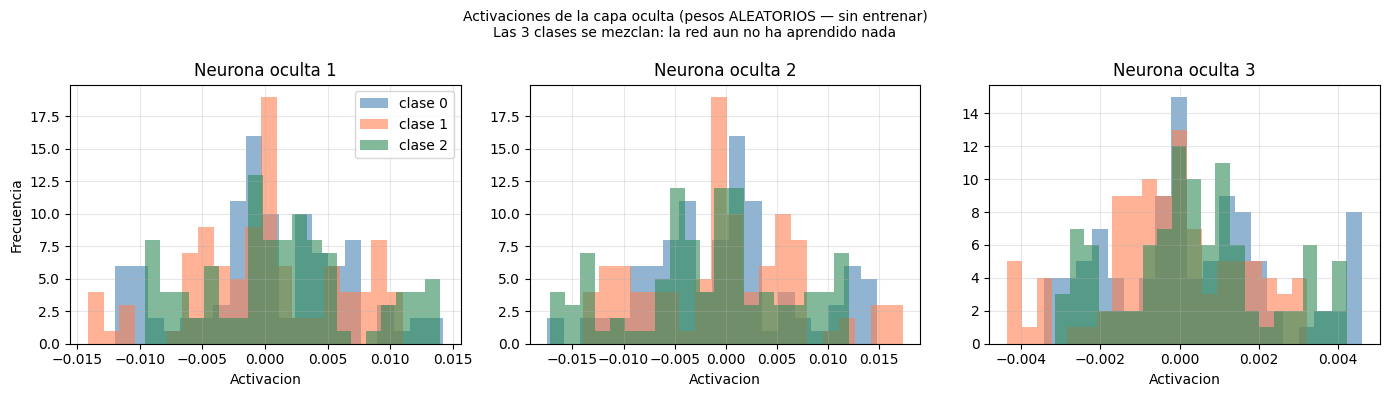

Tras el entrenamiento, estas distribuciones se separan:
cada neurona aprendera a detectar un patron distinto para cada clase.


In [8]:
# Visualizar activaciones de la capa oculta

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Activaciones de cada neurona de la capa 1 (pesos aleatorios)
for i in range(3):
    for clase in range(3):
        mask = y == clase
        axes[i].hist(dense1.output[mask, i], bins=20, alpha=0.6,
                     color=colores[clase], label=f'clase {clase}')
    axes[i].set_title(f'Neurona oculta {i+1}')
    axes[i].set_xlabel('Activacion')
    if i == 0:
        axes[i].set_ylabel('Frecuencia')
        axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Activaciones de la capa oculta (pesos ALEATORIOS - sin entrenar)\n'
             'Las 3 clases se mezclan: la red aun no ha aprendido nada', fontsize=10)
plt.tight_layout()
plt.savefig('images/B03B_fig02.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close('all')

print('Tras el entrenamiento, estas distribuciones se separan:')
print('cada neurona aprendera a detectar un patron distinto para cada clase.')

---
## 6. Ejercicio de decisión

### Caso: modelo de scoring de riesgo para clientes la empresa

El equipo de ventas quiere un modelo que clasifique cada cliente en:
- **low_risk**: cliente consolidado, renovación probable
- **mid_risk**: cliente con señales mixtas
- **high_risk**: cliente que probablemente no renueve

Tienen 800 clientes históricos con etiquetas (asignadas por analistas).
Features disponibles: 12 variables de uso del producto.

Un desarrollador propone usar una red de **5 capas ocultas de 256 neuronas cada una**.

---

**Pregunta 1 - La arquitectura**:
¿Tiene sentido una red de 5 capas con 256 neuronas para 800 muestras y 12 features?
¿Qué problema anticipas?

**Pregunta 2 - Dimensión de entrada y salida**:
Si usas esta arquitectura, ¿cuántas entradas tiene la primera capa?
¿Cuántas salidas tiene la última capa?

**Pregunta 3 - Lineal vs no lineal**:
¿Necesitas funciones de activación no lineales aquí?
¿Qué perdería el modelo si todas las capas fueran lineales?

**Pregunta 4 - Decisión**:
¿Qué arquitectura propondrías tú? Justifica el número de capas y neuronas.

---
*Escribe tus respuestas en la celda siguiente.*

### Mis respuestas

**Pregunta 1 - La arquitectura:**

*(escribe aquí)*

**Pregunta 2 - Dimensión de entrada y salida:**

*(escribe aquí)*

**Pregunta 3 - Lineal vs no lineal:**

*(escribe aquí)*

**Pregunta 4 - Arquitectura propuesta:**

*(escribe aquí)*

---

<!--
CRITERIOS DE EVALUACION (para el instructor)

Pregunta 1:
5 capas x 256 neuronas = ~330.000 parámetros para 800 muestras.
Proporción parámetros/muestras altísima -> sobreajuste casi garantizado.
Regla orientativa: empezar con la menor complejidad que resuelve el problema.
Para 800 muestras y 12 features: 1-2 capas de 16-64 neuronas es un punto de partida razonable.

Pregunta 2:
Primera capa: n_inputs = 12 (una por feature).
Última capa: n_neurons = 3 (una por clase: low_risk, mid_risk, high_risk).
Penalizar confundir entradas con salidas, o no saber que las salidas deben coincidir con las clases.

Pregunta 3:
Si todas las capas son lineales, cualquier red profunda colapsa a una sola transformación lineal
(W_efectiva = W5@W4@W3@W2@W1). La profundidad no aporta nada.
Las funciones de activación no lineales (ReLU) son las que permiten aprender relaciones complejas.
Un alumno que solo dice 'si, necesito activaciones' sin explicar por que tiene respuesta incompleta.

Pregunta 4:
Respuesta sólida: 1-2 capas ocultas, empezar con pocas neuronas (16-32),
evaluar con validation set, añadir complejidad solo si el error de validación lo justifica.
Mencionar regularización (dropout) si propone más capas.
Penalizar: 'más capas = mejor' sin mencionar el riesgo de sobreajuste.
-->

---
## Puntos clave del B03B

1. **Encadenar capas**: la salida de la capa N es la entrada de la capa N+1.
   La restricción es que `n_inputs` de la capa N+1 == `n_neurons` de la capa N.

2. **`Layer_Dense` encapsula la inicialización y el forward pass**:
   pesos `(n_inputs, n_neurons)` ya en el orden correcto para `np.dot`.

3. **Pesos pequeños al inicio** (`0.01 * randn`): evitan que el entrenamiento
   empiece con gradientes desproporcionadamente grandes.

4. **Los datos no lineales requieren capas ocultas**: una sola capa densa
   equivale a un modelo lineal. Las espirales no son separables linealmente.

5. **Con pesos aleatorios, la red produce ruido**. El entrenamiento (B04)
   ajustará los pesos para que las predicciones sean correctas.

---
**Siguiente notebook** - B03C: Funciones de Activación
Añadiremos no linealidad: ReLU para capas ocultas y Softmax para la salida.